# Synthetic Data Experiment Series

## 02 - Hierarchical Two-layer Mixture

This notebook samples synthetic data from a **two-layer Mixture-of-mixture distributions**.

Then compares a mixture of Cylindrical and a mixture-of-mixtures perfomances in learning such data.

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np

%matplotlib widget
import soccer_pattern_recognition as spr
from experiment.synthetic_data import experiment_helper as mod


rng = np.random.RandomState(7)
D_GAUSS = mod.D_GAUSS
D_VMF = mod.D_VMF
N = 10000

### Data Generation


In [2]:
def unit(v):
    v = np.asarray(v, dtype=float)
    if v.ndim == 1:
        norm = np.linalg.norm(v)
        return v / max(norm, 1e-12)
    else:
        norm = np.linalg.norm(v, axis=-1, keepdims=True)
        return v / np.clip(norm, 1e-12, None)

In [18]:
def spd_from_factor(F, jitter=0.08):
    F = np.asarray(F, dtype=float)
    return F @ F.T + jitter * np.eye(F.shape[0])

l1_means = [
    np.array([-1.0,  0.2,  0.1]),
    np.array([-0.2, -0.4,  0.0]),
    np.array([ 0.5,  0.1, -0.2]),
    np.array([ 1.0, -0.2,  0.2]),
]

l1_factors = [
    np.array([[ 1.10,  0.50,  0.20],
              [ 0.80,  0.60,  0.10],
              [ 0.40,  0.20,  0.80]]),
    np.array([[ 1.00, -0.60,  0.20],
              [-0.70,  1.00, -0.30],
              [ 0.20, -0.50,  0.90]]),
    np.array([[ 1.20,  0.70, -0.20],
              [ 0.50,  0.90,  0.40],
              [-0.10,  0.30,  0.80]]),
    np.array([[ 1.10, -0.50,  0.30],
              [-0.40,  0.80,  0.50],
              [ 0.30,  0.40,  0.90]]),
]

layer1_components = [
    spr.MultivariateGaussian(D_GAUSS, mean=m, covariance=spd_from_factor(F))
    for m, F in zip(l1_means, l1_factors)
]

layer1_mixture = spr.MixtureModel(
    layer1_components,
    weights=np.array([0.15, 0.35, 0.30, 0.20], dtype=float),
    init="k-means",
)

# --- Layer 2: similar directions across groups + one diffuse component ---
layer2_specs = [
    [(unit([1.00, 0.25, 0.05]), 6.0),
     (unit([0.90, 0.40, 0.15]), 4.5),
     (unit([0.80,-0.05, 0.60]), 2.2)],

    [(unit([0.95, 0.15,-0.05]), 5.5),
     (unit([0.88, 0.48, 0.10]), 4.0),
     (unit([0.78,-0.20, 0.58]), 2.0)],

    [(unit([0.92, 0.10, 0.10]), 5.0),
     (unit([0.86, 0.42, 0.22]), 3.8),
     (unit([0.73,-0.10, 0.67]), 1.8)],

    [(unit([0.89, 0.30,-0.02]), 4.8),
     (unit([0.83, 0.50, 0.20]), 3.5),
     (unit([0.70,-0.18, 0.69]), 1.7)],
]

layer2_weights = [
    np.array([0.60, 0.30, 0.10], dtype=float),
    np.array([0.55, 0.30, 0.15], dtype=float),
    np.array([0.45, 0.40, 0.15], dtype=float),
    np.array([0.50, 0.25, 0.25], dtype=float),
]

layer2_mixtures = []
for specs, w in zip(layer2_specs, layer2_weights):
    comps = [spr.VonMisesFisher(D_VMF, mu=mu, kappa=kappa) for mu, kappa in specs]
    layer2_mixtures.append(spr.MixtureModel(comps, weights=w, init="k-means"))

mom = spr.TwoLayerMoM(layer1_mixture=layer1_mixture, layer2_mixtures=layer2_mixtures)
x = mom.sample(N, rng=rng)

In [19]:
x_gauss = x[:, :D_GAUSS]
x_vmf = x[:, D_GAUSS:]

In [20]:
# medium noise setup
sigma_g = 0.15 * np.maximum(x_gauss.std(axis=0, ddof=1), 1e-8)
sigma_v = 0.05

noise_g = rng.normal(0.0, sigma_g, size=(N, D_GAUSS))
noise_v = rng.normal(0.0, sigma_v, size=(N, D_VMF))

x_noisy_gauss = noise_g + x_gauss
x_noisy_vmf = noise_v + x_vmf

# re-project directional block to unit sphere (required for vMF)
x_noisy_vmf = unit(x_noisy_vmf)
x_noisy = np.concatenate((x_noisy_gauss, x_noisy_vmf), axis=1)

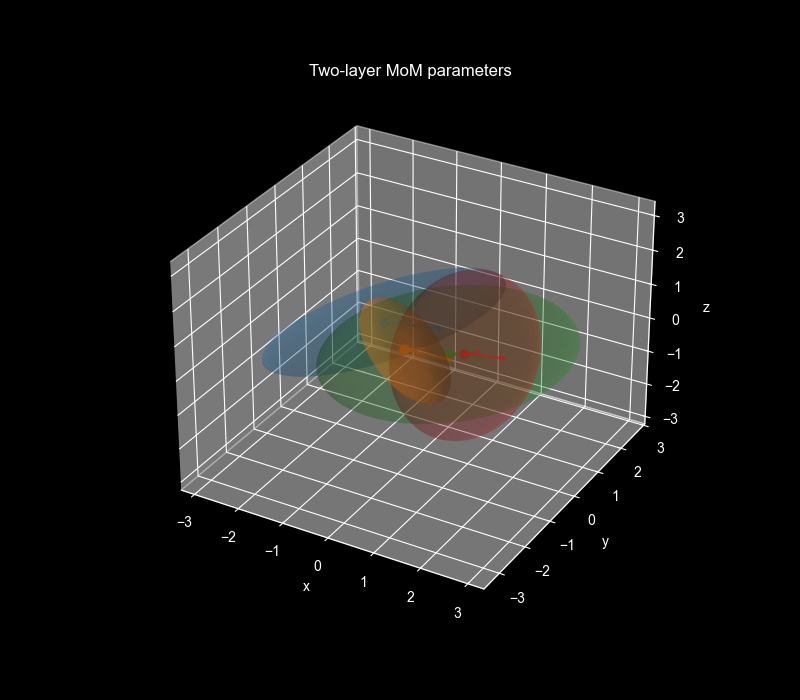

In [21]:
fig, ax = mod.plot_mom_components(mom, arrow_scale=2.0)

### Model Training

In [22]:
search = spr.calibrate_mixture_by_bic_grid_search(
    x,
    n_components_grid=(3, 4, 5),
    n_restarts=2,
    init="k-means++",
    model_builder=mod.cylindrical_mixture_builder_3d,
    tol=1e-4,
    max_iter=300,
    m_step_case="bregman",
    random_state=42,
)

cyl_mm = search["best_model"]
print("Best BIC:", search["best_bic"])
print("Best config:", search["best_config"])

Best BIC: 122425.24765055835
Best config: {'n_components': 4, 'restart': 0, 'seed': 1935803228, 'n_iter': 43}


In [23]:
search = spr.calibrate_mixture_by_bic_grid_search(
    x_noisy,
    n_components_grid=(3, 4, 5),
    n_restarts=2,
    init="k-means++",
    model_builder=mod.cylindrical_mixture_builder_3d,
    tol=1e-4,
    max_iter=300,
    m_step_case="bregman",
    random_state=42,
)

noisy_cyl_mm = search["best_model"]
print("Best BIC:", search["best_bic"])
print("Best config:", search["best_config"])

Best BIC: 124329.84664573516
Best config: {'n_components': 4, 'restart': 1, 'seed': 787846414, 'n_iter': 39}


In [24]:
search = spr.calibrate_mom_by_bic_grid_search(
    layer1_data=x_gauss,
    layer2_data=x_vmf,
    n_layer1_grid=(3, 4, 5),
    n_layer2_grid=(1, 2, 3),
    n_restarts=3,
    init_layer1="k-means++",
    init_layer2="k-means++",
    model_builder=mod.mom_builder_3d,
    m_step_case="bregman",
    tol=1e-4,
    max_iter=300,
    random_state=42,
)

cyl_mom = search["best_model"]
print("Best BIC:", search["best_bic"])
print("Best config:", search["best_config"])

Best BIC: 122093.01874607989
Best config: {'n_layer1_components': 4, 'n_layer2_components': 2, 'restart': 0, 'seed': 249467210, 'n_iter': 41}


In [25]:
search = spr.calibrate_mom_by_bic_grid_search(
    layer1_data=x_noisy_gauss,
    layer2_data=x_noisy_vmf,
    n_layer1_grid=(3, 4, 5),
    n_layer2_grid=(1, 2, 3),
    n_restarts=3,
    init_layer1="k-means++",
    init_layer2="k-means++",
    model_builder=mod.mom_builder_3d,
    m_step_case="bregman",
    tol=1e-4,
    max_iter=300,
    random_state=42,
)

noisy_cyl_mom = search["best_model"]
print("Best BIC:", search["best_bic"])
print("Best config:", search["best_config"])

Best BIC: 124006.62082852206
Best config: {'n_layer1_components': 4, 'n_layer2_components': 2, 'restart': 1, 'seed': 1972458954, 'n_iter': 52}


### Model Comparison

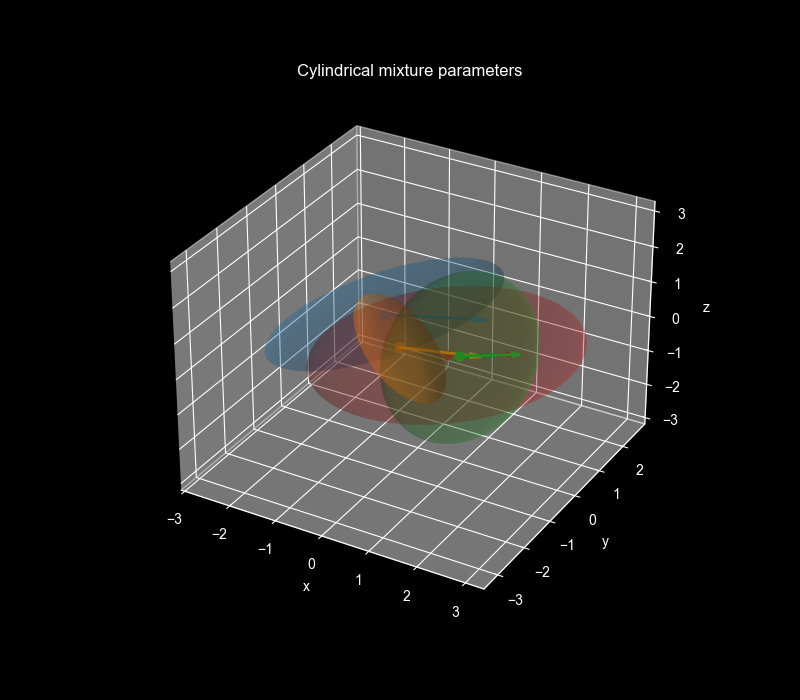

In [26]:
fig, ax = mod.plot_cylindrical_components(cyl_mm, arrow_scale=2.0)

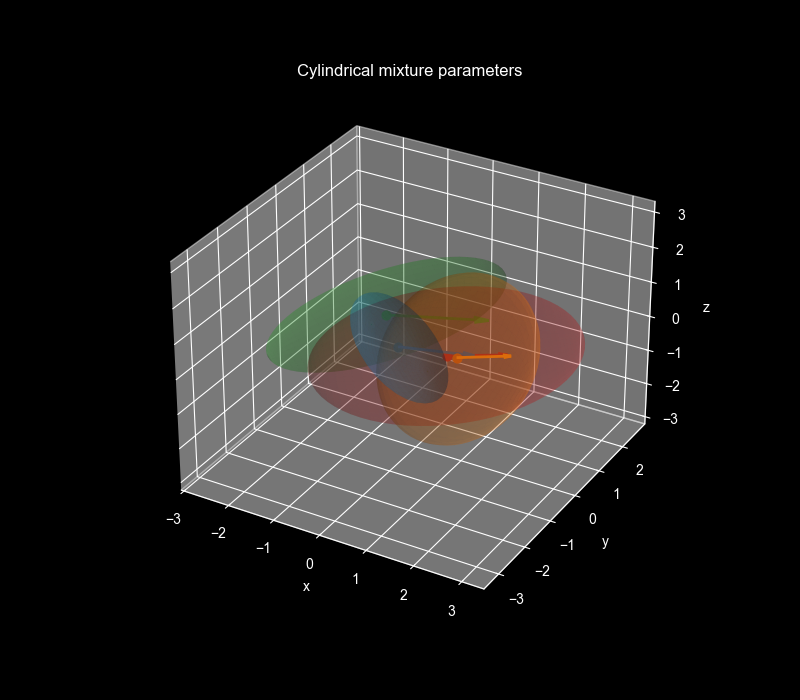

In [27]:
fig, ax = mod.plot_cylindrical_components(noisy_cyl_mm, arrow_scale=2.0)

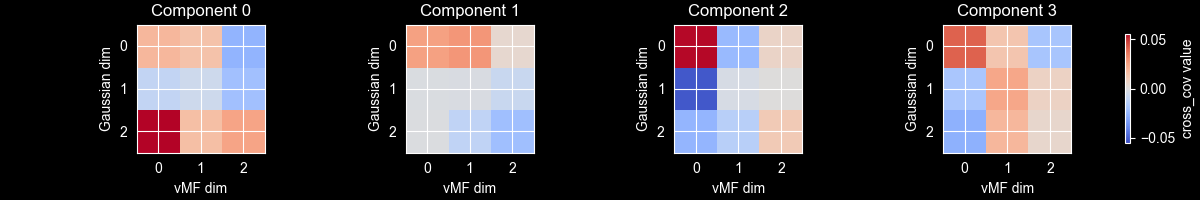

In [28]:
mod.plot_cross_cov_matrices(cyl_mm.components, cmap="coolwarm")

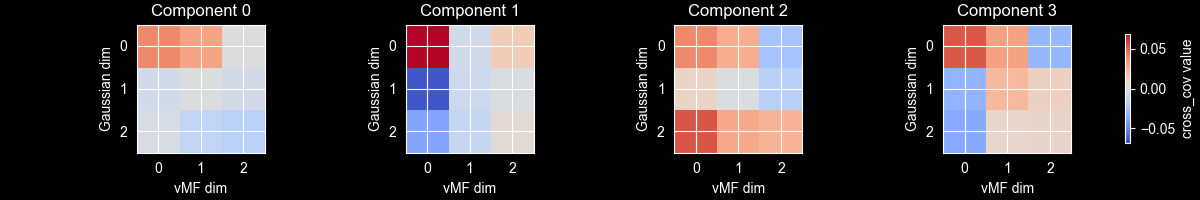

In [29]:
mod.plot_cross_cov_matrices(noisy_cyl_mm.components, cmap="coolwarm")

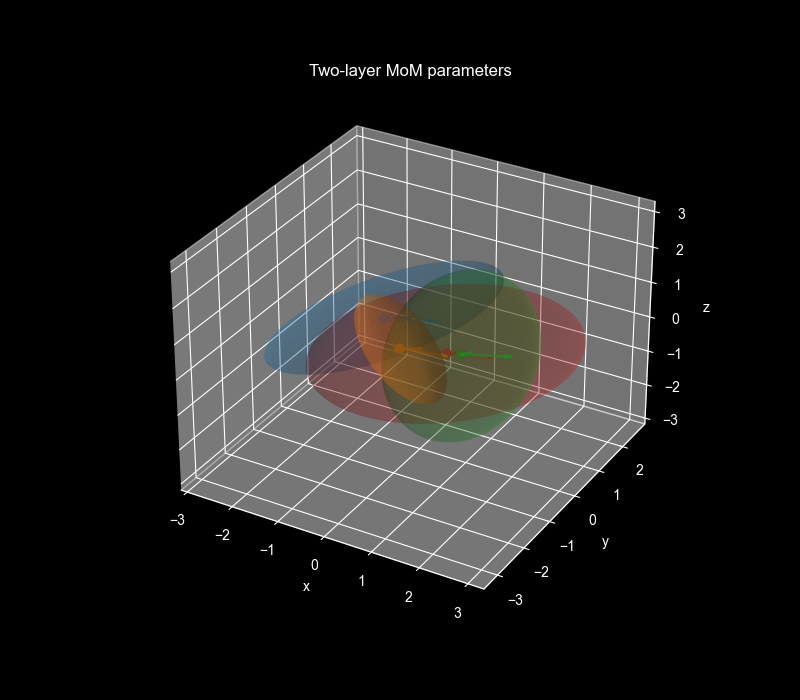

In [30]:
fig, ax = mod.plot_mom_components(cyl_mom, arrow_scale=2.0)

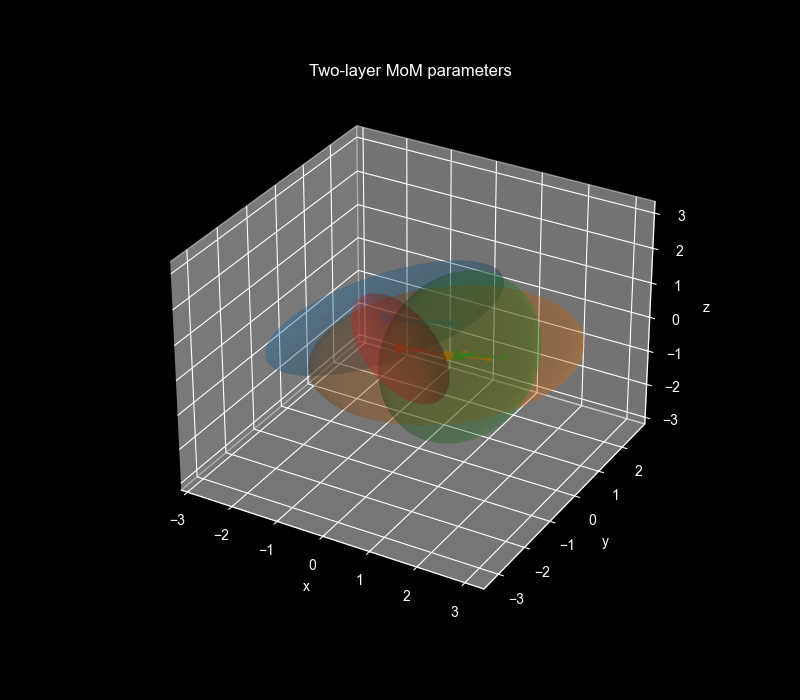

In [31]:
fig, ax = mod.plot_mom_components(noisy_cyl_mom, arrow_scale=2.0)

In [32]:
print(f"Cyl. Mixture BIC: {cyl_mm.bic_score(x):.2f}")
print(f"MoM BIC: {cyl_mom.bic_score(x_gauss, x_vmf):.2f}")
print(f"Cyl. Mixture Log-likelihood: {cyl_mm.log_pdf(x).sum():.2f}")
print(f"MoM Log-likelihood: {cyl_mom.log_pdf(x_gauss, x_vmf).sum():.2f}")

print(f"Noisy Cyl. Mixture BIC: {noisy_cyl_mm.bic_score(x_noisy):.2f}")
print(f"Noisy MoM BIC: {noisy_cyl_mom.bic_score(x_noisy_gauss, x_noisy_vmf):.2f}")
print(f"Noisy Cyl. Mixture Log-likelihood: {noisy_cyl_mm.log_pdf(x_noisy).sum():.2f}")
print(f"Noisy MoM Log-likelihood: {noisy_cyl_mom.log_pdf(x_noisy_gauss, x_noisy_vmf).sum():.2f}")

Cyl. Mixture BIC: 122425.25
MoM BIC: 122093.02
Cyl. Mixture Log-likelihood: -60811.97
MoM Log-likelihood: -60737.96
Noisy Cyl. Mixture BIC: 124329.85
Noisy MoM BIC: 124006.62
Noisy Cyl. Mixture Log-likelihood: -61764.27
Noisy MoM Log-likelihood: -61694.76
